# 😊 NLP Sentiment Analysis Project

## Projenin Amacı

Bu projede kullanıcı yorumlarının pozitif veya negatif olduğunu tahmin eden bir doğal dil işleme (NLP) modeli geliştirilecektir.

Amaç metin verileri üzerinde duygu analizi gerçekleştirmektir.

---

## Kullanılan Teknolojiler

- Python
- Pandas
- NumPy
- Scikit-learn
- TensorFlow / Keras
- Matplotlib
- NLP

---

## Proje Yol Haritası

1. Dataset yükleme  
2. Veri temizleme  
3. Metin ön işleme  
4. Tokenization işlemi  
5. Padding işlemi  
6. Train/Test ayırma  
7. Deep Learning modeli oluşturma  
8. Model eğitimi  
9. Accuracy analizi  
10. Sonuç değerlendirmesi

In [1]:
# Dataset yolunu kontrol ediyoruz

import os

for dirname, _, files in os.walk("/kaggle/input"):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/lakshmi25npathi
/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
/kaggle/input/notebooks
/kaggle/input/notebooks/alimohtadi
/kaggle/input/notebooks/alimohtadi/imdb-dataset-of-50k-movie-reviews


# 😊 NLP Sentiment Analysis Project

## Projenin Amacı

Bu projede kullanıcı yorumlarının pozitif veya negatif olduğunu tahmin eden bir doğal dil işleme (NLP) modeli geliştirilecektir.

Amaç metin verileri üzerinde duygu analizi gerçekleştirmektir.

---

## Kullanılan Teknolojiler

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- NLP
- TF-IDF Vectorizer

---

## Proje Yol Haritası

1. Dataset yükleme
2. Veri setini inceleme
3. Veri temizleme
4. Metin ön işleme
5. TF-IDF dönüşümü
6. Train-Test ayırma
7. Logistic Regression modeli
8. Naive Bayes modeli
9. Random Forest modeli
10. Accuracy karşılaştırması
11. Confusion Matrix
12. Sonuçların yorumlanması

In [2]:
# Gerekli kütüphaneleri içe aktarıyoruz

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 📂 Dataset Yükleme

Bu bölümde IMDB film yorumları veri seti okunacaktır. Veri setinde kullanıcı yorumları ve bu yorumların pozitif/negatif duygu etiketleri bulunmaktadır.

In [3]:
# IMDB datasetini KaggleHub ile indiriyoruz

import kagglehub

dataset_path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print(dataset_path)

/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews


In [4]:
# CSV dosyasını okuyoruz

import os
import pandas as pd

base_path = "/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews"

print(os.listdir(base_path))

['IMDB Dataset.csv']


In [5]:
# Dataseti yüklüyoruz

df = pd.read_csv("/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")

print(df.shape)

df.head()

(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# 🔎 Veri Setini İnceleme

Bu bölümde veri setinin boş değer durumu, veri tipleri ve sınıf dağılımları analiz edilmektedir.

In [6]:
# Veri seti hakkında genel bilgi alıyoruz

print(df.info())

print("\nEksik Veri Sayıları:\n")
print(df.isnull().sum())

print("\nSınıf Dağılımı:\n")
print(df["sentiment"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None

Eksik Veri Sayıları:

review       0
sentiment    0
dtype: int64

Sınıf Dağılımı:

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


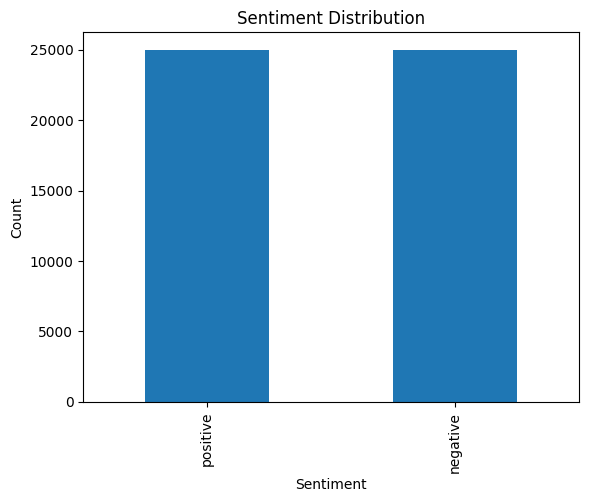

In [7]:
# Pozitif ve negatif yorum dağılımını görselleştiriyoruz

df["sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

# 🧹 Metin Temizleme (Text Preprocessing)

Bu bölümde yorum metinleri temizlenecek ve modelleme için uygun hale getirilecektir.

Yapılan işlemler:

- Küçük harfe çevirme
- HTML etiketlerini temizleme
- Noktalama işaretlerini kaldırma
- Sayıları kaldırma

In [8]:
# Yorum metinlerini temizliyoruz

def clean_text(text):

    text = text.lower()

    text = re.sub(r"<.*?>", "", text)

    text = re.sub(r"[^a-zA-Z]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text

df["clean_review"] = df["review"].apply(clean_text)

df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is a...


In [9]:
# Pozitif ve negatif etiketleri sayısala çeviriyoruz

df["sentiment"] = df["sentiment"].map({
    "positive":1,
    "negative":0
})

df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,1,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,1,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,1,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,0,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter mattei s love in the time of money is a...


# 🔤 TF-IDF Dönüşümü

Bu bölümde metin verileri sayısal formata dönüştürülmektedir.

TF-IDF yöntemi ile kelimelerin önem dereceleri hesaplanarak modele uygun hale getirilecektir.

In [10]:
# TF-IDF dönüşümü yapıyoruz

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["clean_review"])

y = df["sentiment"]

print(X.shape)
print(y.shape)

(50000, 5000)
(50000,)


# ✂️ Train - Test Ayırma

Veri seti eğitim ve test verileri olarak ikiye ayrılmaktadır.

In [11]:
# Train test ayırma işlemi

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(40000, 5000)
(10000, 5000)


# 🤖 Logistic Regression Modeli

İlk model olarak Logistic Regression algoritması kullanılacaktır.

In [12]:
# Logistic Regression modelini eğitiyoruz

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.8942


# 📊 Naive Bayes Modeli

İkinci model olarak Multinomial Naive Bayes algoritması kullanılacaktır.

In [13]:
# Naive Bayes modelini eğitiyoruz

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

nb_acc = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.8526


# 🌲 Random Forest Modeli

Üçüncü model olarak Random Forest algoritması kullanılacaktır.

In [14]:
# Random Forest modelini eğitiyoruz

rf_model = RandomForestClassifier(n_estimators=100)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.8484


# 📈 Model Başarı Karşılaştırması

Bu bölümde kullanılan modellerin doğruluk oranları karşılaştırılacaktır.

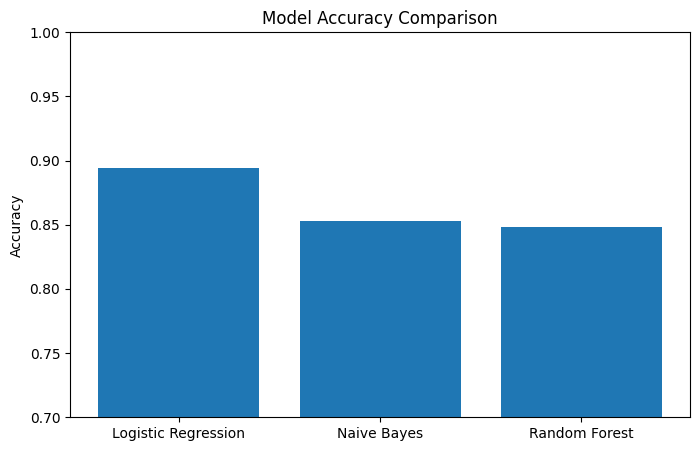

In [15]:
# Modellerin başarı oranlarını görselleştiriyoruz

models = ["Logistic Regression", "Naive Bayes", "Random Forest"]

scores = [lr_acc, nb_acc, rf_acc]

plt.figure(figsize=(8,5))

plt.bar(models, scores)

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.ylim(0.7,1.0)

plt.show()

# 🔍 Confusion Matrix

En başarılı model için confusion matrix oluşturulacaktır.

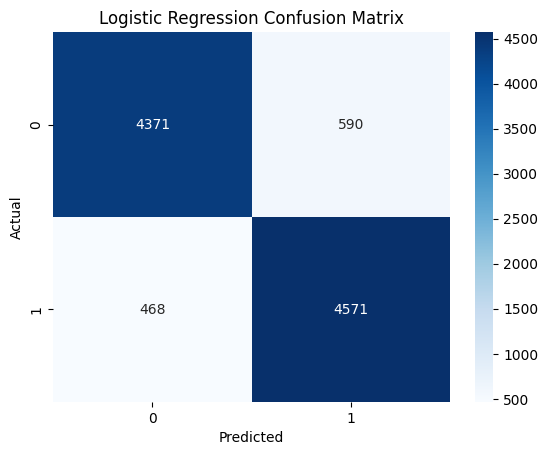

In [16]:
# Logistic Regression confusion matrix

cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ✅ Proje Sonuçları

Bu projede IMDB film yorumları üzerinde duygu analizi gerçekleştirilmiştir.

Metin verileri temizlenmiş ve TF-IDF yöntemi ile sayısal hale dönüştürülmüştür.

Daha sonra üç farklı makine öğrenmesi modeli kullanılmıştır:

- Logistic Regression
- Naive Bayes
- Random Forest

Karşılaştırma sonucunda en başarılı modelin Logistic Regression olduğu gözlemlenmiştir.

Bu proje sayesinde doğal dil işleme (NLP) süreçleri, metin temizleme işlemleri, feature extraction ve sınıflandırma algoritmaları uygulanmıştır.